# Aligned EN–FR Sentiment Comparison (Budget 2025)

Sentence-aligned English and French segments from LF Aligner output in `data/aligned/`.

**Chaque segment aligné** reçoit une étiquette (négatif / neutre / positif) et un score de confiance. Nous comparons les profils par type d'alignement et les accords EN–FR sur **deux chaînes d'analyse** pour repérer les décalages émotionnels entre traductions.

| Chain | EN | FR side |
|-------|-----|---------|
| **A — Multilingual** | XLM-RoBERTa | XLM-RoBERTa (same model) |
| **B — Monolingual** | FinBERT | CamemBERT |

Run the **next code cell** once to install packages. First full run downloads model weights and caches results under `data/outputs/`. Set `RERUN_INFERENCE = True` if you have a stale cache from an older notebook version.


In [1]:

# Run once — installs into this notebook's Python kernel
import subprocess
import sys

_PACKAGES = [
    "pandas>=2.2.0",
    "matplotlib>=3.8.0",
    "seaborn>=0.13.0",
    "tqdm>=4.66.0",
    "torch>=2.0.0",
    "transformers>=4.38.0",
    "sentencepiece>=0.1.99",
    "accelerate>=0.27.0",
    "protobuf>=3.20.0",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_PACKAGES])
print("Done. Python:", sys.executable)


Done. Python: /usr/local/bin/python3.13



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip


In [2]:

from __future__ import annotations

import platform
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "data" / "aligned").is_dir():
    REPO_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "data" / "aligned").is_dir():
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    raise RuntimeError("Run from repo root or data/ so data/aligned is found")

ALIGNED_DIR = REPO_ROOT / "data" / "aligned"
OUTPUT_DIR = REPO_ROOT / "data" / "outputs"
FIGURES_DIR = REPO_ROOT / "data" / "figures" / "aligned_sentiment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ALIGN_TAG = "v29.4.2"
SUMMARY_PATH = ALIGNED_DIR / f"alignment_summary{ALIGN_TAG}.tsv"
DIAGNOSTIC_PATH = ALIGNED_DIR / f"budget-2025_diagnostic{ALIGN_TAG}.tsv"
ALIGN_PATH = ALIGNED_DIR / f"budget-2025_align{ALIGN_TAG}.txt"
REJECT_PATH = ALIGNED_DIR / f"budget-2025_reject{ALIGN_TAG}.txt"
CACHE_PATH = OUTPUT_DIR / f"aligned_sentiment_{ALIGN_TAG}.csv"

MODEL_XLM = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
MODEL_FINBERT = "ProsusAI/finbert"
MODEL_CAMEMBERT = "cardiffnlp/camembert-base-tweet-sentiment-fr"

BATCH_SIZE = 16
RERUN_INFERENCE = False
MAX_PAIRS = None  # e.g. 200 for smoke test; None = all (~3,001)
SAVE_FIGURES = True

if torch.cuda.is_available():
    DEVICE = 0
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = -1

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12})
SENTIMENT_COLORS = {
    "negative": "#c0392b",
    "neutral": "#7f8c8d",
    "positive": "#27ae60",
}
CHAIN_LABELS = {
    "xlm": "A: XLM-R (multilingual)",
    "mono": "B: FinBERT + CamemBERT",
}


def savefig(name: str) -> None:
    if SAVE_FIGURES:
        plt.savefig(FIGURES_DIR / name, bbox_inches="tight", dpi=120)


## 1. Load alignment data


In [3]:

def load_diagnostic_pairs(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df = df.rename(columns={"src_text": "en_text", "tgt_text": "fr_text", "step_idx": "pair_id"})
    df["year"] = 2025
    df["en_words"] = df["en_text"].astype(str).str.split().str.len()
    df["fr_words"] = df["fr_text"].astype(str).str.split().str.len()
    return df


summary = pd.read_csv(SUMMARY_PATH, sep="\t")
pairs = load_diagnostic_pairs(DIAGNOSTIC_PATH)

if MAX_PAIRS is not None:
    pairs = pairs.head(min(MAX_PAIRS, len(pairs))).copy()

print("Alignment summary:")
display(summary)
print(f"\nDiagnostic pairs loaded: {len(pairs):,}")
print("\nCounts by alignment type (typ):")
display(pairs["typ"].value_counts().to_frame("n"))

pairs[["pair_id", "typ", "semantic", "step_score", "en_words", "fr_words"]].describe().round(3)


Alignment summary:


,document,total_steps,detailed_steps,bilingual_steps,gap_steps,final_score,coverage_src,coverage_tgt,precision,recall,f1
0,budget-2025,1524,3001,1524,0,922.203352,1.0,1.0,0.998031,1.0,0.999015



Diagnostic pairs loaded: 3,001

Counts by alignment type (typ):


,n
typ,
1-1,2352
2-2,310
2-1,217
3-1,55
1-2,46
3-2,10
3-3,4
2-3,3
1-3,2


,pair_id,semantic,step_score,en_words,fr_words
count,3001.000,3001.000,3001.000,3001.000,3001.000
mean,1501.000,0.861,0.574,33.247,42.198
std,866.458,0.097,0.114,61.802,74.734
min,1.000,0.000,-1.974,1.000,1.000
25%,751.000,0.820,0.532,15.000,20.000
50%,1501.000,0.885,0.582,25.000,32.000
75%,2251.000,0.926,0.639,37.000,48.000
max,3001.000,1.000,0.849,1778.000,2629.000


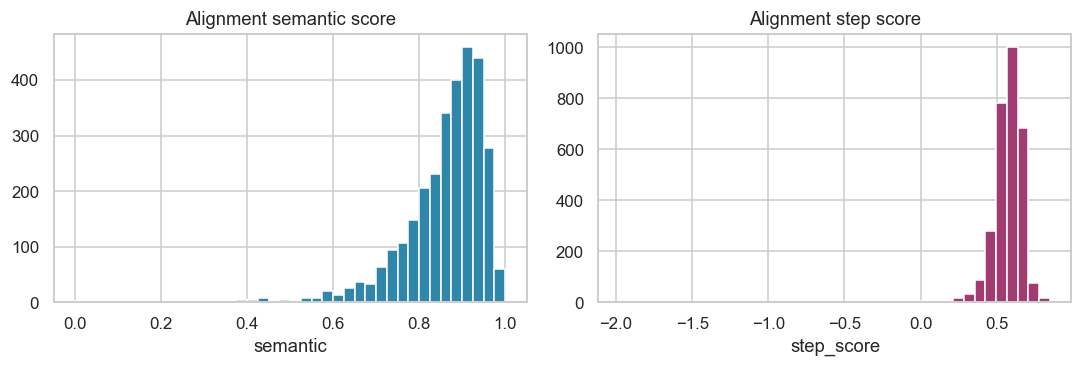

,pair_id,typ,semantic,en_text,fr_text
0,1,1-1,0.789302,Table of contents,Table des matières
1,2,2-2,0.920925,Our plan: Building Canada strong Global Genera...,Notre plan : Bâtir un Canada fort Un monde en ...
2,3,1-1,0.879088,"Economic and fiscal overview A Changing World,...",Aperçu de la situation économique et budgétair...


In [4]:

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(pairs["semantic"].dropna(), bins=40, color="#2E86AB", edgecolor="white")
axes[0].set_xlabel("semantic")
axes[0].set_title("Alignment semantic score")
axes[1].hist(pairs["step_score"].dropna(), bins=40, color="#A23B72", edgecolor="white")
axes[1].set_xlabel("step_score")
axes[1].set_title("Alignment step score")
plt.tight_layout()
savefig("alignment_score_histograms.png")
plt.show()

pairs[["pair_id", "typ", "semantic", "en_text", "fr_text"]].head(3)


## 2. Sentiment inference (two chains)


In [5]:

def normalize_label(raw: str) -> str:
    s = str(raw).lower().strip()
    if s in {"negative", "neg", "0", "label_0"} or "neg" in s:
        return "negative"
    if s in {"positive", "pos", "2", "label_2"} or "pos" in s:
        return "positive"
    return "neutral"


def scores_from_outputs(outputs: list) -> dict:
    normed = []
    for s in outputs:
        lab = normalize_label(s["label"])
        normed.append({"label": lab, "score": float(s["score"])})
    by_label: dict[str, float] = {}
    for s in normed:
        by_label[s["label"]] = max(by_label.get(s["label"], 0.0), s["score"])
    pred = max(normed, key=lambda x: x["score"])["label"]
    return {
        "pred_label": pred,
        "score_negative": by_label.get("negative", np.nan),
        "score_neutral": by_label.get("neutral", np.nan),
        "score_positive": by_label.get("positive", np.nan),
        "confidence": max(by_label.values()) if by_label else np.nan,
        "sentiment_signed": by_label.get("positive", 0.0) - by_label.get("negative", 0.0),
    }


def make_classifier(model_id: str):
    print(f"Loading {model_id} on device={DEVICE} ...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSequenceClassification.from_pretrained(model_id)
    clf = pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=DEVICE,
        top_k=None,
        truncation=True,
        max_length=512,
    )
    print("  id2label:", clf.model.config.id2label)
    return clf


def score_texts(texts: list[str], classifier, desc: str) -> list[dict]:
    records: list[dict] = []
    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc=desc):
        batch = texts[start : start + BATCH_SIZE]
        outputs = classifier(batch)
        for scores in outputs:
            records.append(scores_from_outputs(scores))
    return records


def prefix_records(records: list[dict], prefix: str) -> pd.DataFrame:
    df = pd.DataFrame(records)
    rename = {c: f"{c}_{prefix}" for c in df.columns}
    return df.rename(columns=rename)


def release_model(obj) -> None:
    del obj
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def run_all_chains(df: pd.DataFrame) -> pd.DataFrame:
    base = df.reset_index(drop=True)
    en_texts = base["en_text"].astype(str).tolist()
    fr_texts = base["fr_text"].astype(str).tolist()

    # Chain A — XLM-R on both sides
    xlm = make_classifier(MODEL_XLM)
    en_xlm = prefix_records(score_texts(en_texts, xlm, "XLM EN"), "en_xlm")
    fr_xlm = prefix_records(score_texts(fr_texts, xlm, "XLM FR"), "fr_xlm")
    release_model(xlm)

    # Chain B — FinBERT EN, CamemBERT FR
    fin = make_classifier(MODEL_FINBERT)
    en_fin = prefix_records(score_texts(en_texts, fin, "FinBERT EN"), "en_fin")
    release_model(fin)

    cam = make_classifier(MODEL_CAMEMBERT)
    fr_cam = prefix_records(score_texts(fr_texts, cam, "CamemBERT FR"), "fr_cam")
    release_model(cam)

    return pd.concat([base, en_xlm, fr_xlm, en_fin, fr_cam], axis=1)


if CACHE_PATH.exists() and not RERUN_INFERENCE:
    scored = pd.read_csv(CACHE_PATH)
    print(f"Loaded cache: {CACHE_PATH} ({len(scored):,} rows)")
else:
    scored = run_all_chains(pairs)
    scored.to_csv(CACHE_PATH, index=False)
    print(f"Wrote cache: {CACHE_PATH}")

scored.filter(regex="pred_label").head(3)


Loading cardiffnlp/twitter-xlm-roberta-base-sentiment on device=mps ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}


XLM EN:   0%|          | 0/188 [00:00<?, ?it/s]

XLM FR:   0%|          | 0/188 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}


CamemBERT FR:   0%|          | 0/188 [00:00<?, ?it/s]

Wrote cache: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/outputs/aligned_sentiment_v29.4.2.csv


,pred_label_en_xlm,pred_label_fr_xlm,pred_label_en_fin,pred_label_fr_cam
0,neutral,neutral,neutral,neutral
1,positive,positive,neutral,positive
2,neutral,positive,neutral,positive


## 3. Agreement and sentiment profiles


In [6]:

CHAINS = {
    "xlm": ("pred_label_en_xlm", "pred_label_fr_xlm"),
    "mono": ("pred_label_en_fin", "pred_label_fr_cam"),
}

SIGNED = {
    "xlm": ("sentiment_signed_en_xlm", "sentiment_signed_fr_xlm"),
    "mono": ("sentiment_signed_en_fin", "sentiment_signed_fr_cam"),
}

for key, (en_col, fr_col) in CHAINS.items():
    scored[f"agree_{key}"] = scored[en_col] == scored[fr_col]
    en_s, fr_s = SIGNED[key]
    scored[f"signed_gap_{key}"] = (scored[en_s] - scored[fr_s]).abs()

agreement_rows = []
for key, (en_col, fr_col) in CHAINS.items():
    agreement_rows.append(
        {
            "chain": key,
            "chain_label": CHAIN_LABELS[key],
            "scope": "all",
            "n": len(scored),
            "agreement_rate": scored[f"agree_{key}"].mean(),
        }
    )
    for typ, grp in scored.groupby("typ"):
        agreement_rows.append(
            {
                "chain": key,
                "chain_label": CHAIN_LABELS[key],
                "scope": typ,
                "n": len(grp),
                "agreement_rate": grp[f"agree_{key}"].mean(),
            }
        )

agreement_df = pd.DataFrame(agreement_rows)
display(
    agreement_df[agreement_df["scope"] == "all"][["chain_label", "n", "agreement_rate"]].round(4)
)
display(
    agreement_df[agreement_df["scope"] != "all"]
    .pivot(index="scope", columns="chain", values="agreement_rate")
    .round(3)
)


,chain_label,n,agreement_rate
0,A: XLM-R (multilingual),3001,0.6551
11,B: FinBERT + CamemBERT,3001,0.6275


chain,mono,xlm
scope,,
1-0,1.000,1.000
1-1,0.628,0.663
1-2,0.587,0.652
1-3,1.000,0.500
2-1,0.677,0.608
2-2,0.584,0.665
2-3,0.667,0.667
3-1,0.636,0.473
3-2,0.800,0.300


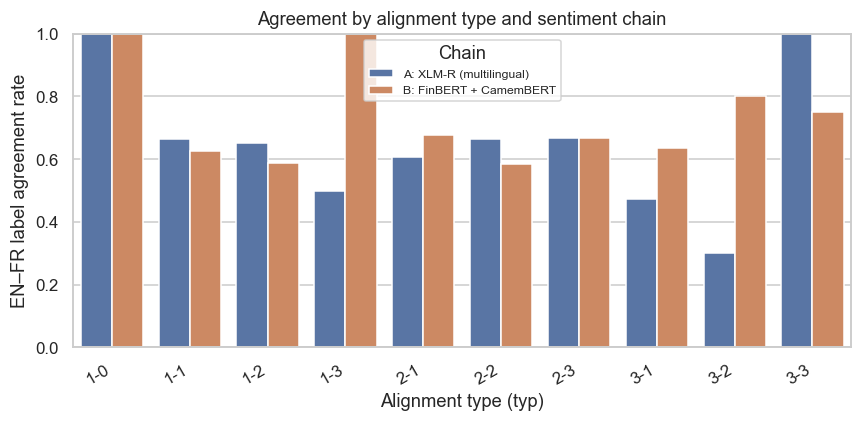

In [7]:

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = agreement_df[agreement_df["scope"] != "all"].copy()
plot_df["chain_label"] = plot_df["chain"].map(CHAIN_LABELS)
sns.barplot(
    data=plot_df,
    x="scope",
    y="agreement_rate",
    hue="chain_label",
    ax=ax,
)
ax.set_ylim(0, 1)
ax.set_xlabel("Alignment type (typ)")
ax.set_ylabel("EN–FR label agreement rate")
ax.set_title("Agreement by alignment type and sentiment chain")
ax.legend(title="Chain", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
savefig("agreement_by_typ_and_chain.png")
plt.show()


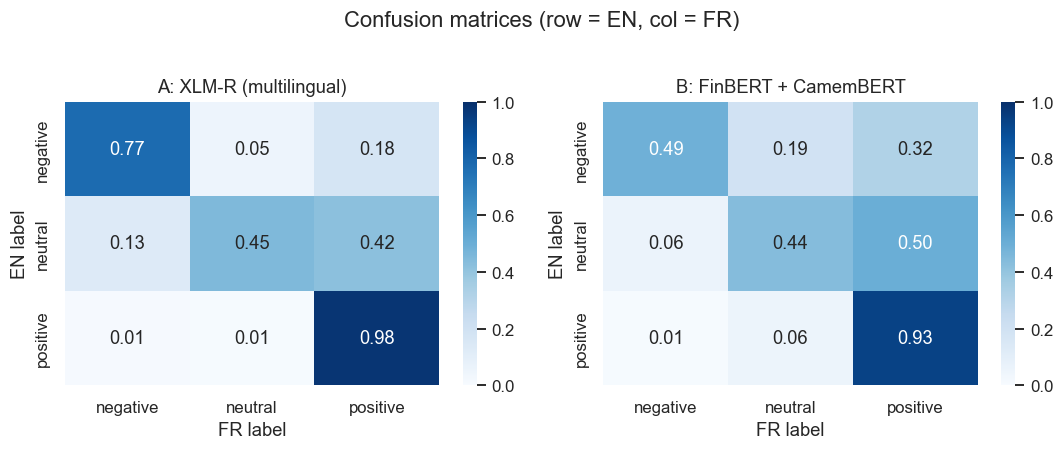

In [8]:

LABELS = ["negative", "neutral", "positive"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (key, (en_col, fr_col)) in zip(axes, CHAINS.items()):
    conf = pd.crosstab(scored[en_col], scored[fr_col], normalize="index").reindex(
        index=LABELS, columns=LABELS, fill_value=0
    )
    sns.heatmap(conf, annot=True, fmt=".2f", cmap="Blues", ax=ax, vmin=0, vmax=1)
    ax.set_xlabel("FR label")
    ax.set_ylabel("EN label")
    ax.set_title(CHAIN_LABELS[key])
fig.suptitle("Confusion matrices (row = EN, col = FR)", y=1.02)
plt.tight_layout()
savefig("confusion_matrices_by_chain.png")
plt.show()


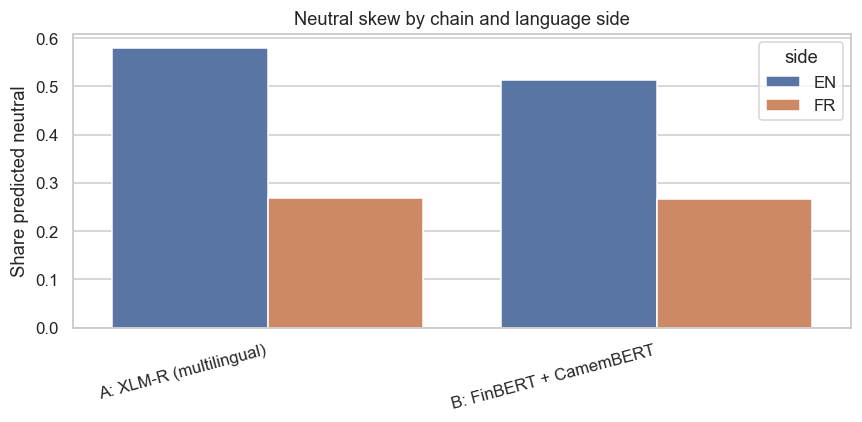

A: XLM-R (multilingual): corr(semantic, signed_gap) = -0.055
B: FinBERT + CamemBERT: corr(semantic, signed_gap) = 0.041


In [9]:

# Neutral-class rate per side and chain
neutral_rows = []
for key, (en_col, fr_col) in CHAINS.items():
    neutral_rows.append(
        {"chain": key, "side": "EN", "neutral_share": (scored[en_col] == "neutral").mean()}
    )
    neutral_rows.append(
        {"chain": key, "side": "FR", "neutral_share": (scored[fr_col] == "neutral").mean()}
    )
neutral_df = pd.DataFrame(neutral_rows)
neutral_df["chain_label"] = neutral_df["chain"].map(CHAIN_LABELS)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=neutral_df, x="chain_label", y="neutral_share", hue="side", ax=ax)
ax.set_ylabel("Share predicted neutral")
ax.set_xlabel("")
ax.set_title("Neutral skew by chain and language side")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
savefig("neutral_share_by_chain.png")
plt.show()

# Correlation: alignment quality vs sentiment signed gap
for key in CHAINS:
    print(
        f"{CHAIN_LABELS[key]}: corr(semantic, signed_gap) = "
        f"{scored['semantic'].corr(scored[f'signed_gap_{key}']):.3f}"
    )


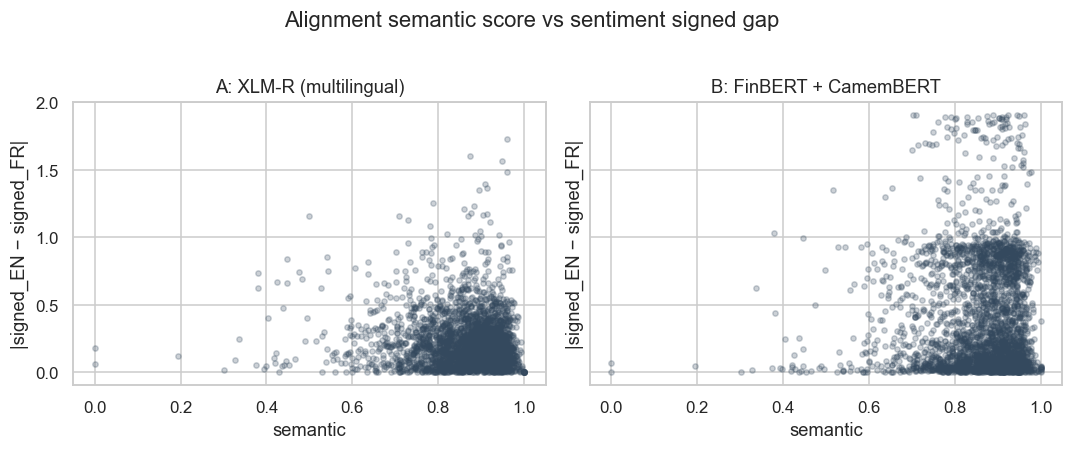

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, key in zip(axes, CHAINS.keys()):
    ax.scatter(
        scored["semantic"],
        scored[f"signed_gap_{key}"],
        alpha=0.25,
        s=12,
        color="#34495e",
    )
    ax.set_xlabel("semantic")
    ax.set_ylabel("|signed_EN − signed_FR|")
    ax.set_title(CHAIN_LABELS[key])
fig.suptitle("Alignment semantic score vs sentiment signed gap", y=1.02)
plt.tight_layout()
savefig("semantic_vs_signed_gap.png")
plt.show()


## 4. Discrepancy mining


In [11]:

def print_aligned_pairs(
    df: pd.DataFrame,
    heading: str,
    max_examples: int = 8,
) -> None:
    print(heading)
    if df.empty:
        print("  (none)\n")
        return
    shown = df.head(max_examples)
    for i, row in enumerate(shown.itertuples(index=False), 1):
        print(f"\n[{i}] typ={row.typ}  semantic={row.semantic:.3f}")
        print(f"    EN: {row.en_text}")
        print(f"    FR: {row.fr_text}")
        print(
            f"    XLM: {row.pred_label_en_xlm}/{row.pred_label_fr_xlm}  "
            f"Mono: {row.pred_label_en_fin}/{row.pred_label_fr_cam}"
        )
    if len(df) > len(shown):
        print(f"\n  … and {len(df) - len(shown)} more.\n")
    else:
        print()


# High semantic alignment but sentiment disagreement (XLM chain)
high_sem_disagree = scored[
    (scored["semantic"] >= 0.85) & (~scored["agree_xlm"])
].sort_values("semantic", ascending=False)

print_aligned_pairs(
    high_sem_disagree,
    f"\n{'=' * 72}\nHigh alignment (semantic≥0.85) but XLM labels differ "
    f"({len(high_sem_disagree)} pairs)",
    max_examples=10,
)



High alignment (semantic≥0.85) but XLM labels differ (648 pairs)

[1] typ=1-1  semantic=0.994
    EN: 3.3 Protecting Canadian Culture, Values, and Identity
    FR: 3.3 Protéger la culture, l'identité et les valeurs canadiennes
    XLM: neutral/positive  Mono: neutral/positive

[2] typ=1-1  semantic=0.983
    EN: 5.2 Modernising Services
    FR: 5.2 Moderniser les services
    XLM: neutral/positive  Mono: neutral/positive

[3] typ=1-1  semantic=0.983
    EN: In accordance with the Cabinet Directive on Strategic Environmental and Economic Assessment, a strategic economic assessment was conducted for the following measures:
    FR: Conformément à la Directive du Cabinet sur l'évaluation environnementale et économique stratégique, une évaluation économique stratégique a été réalisée pour les mesures suivantes :
    XLM: neutral/positive  Mono: neutral/positive

[4] typ=1-1  semantic=0.982
    EN: In addition, the new rules would modify certain administrative measures.
    FR: En outre, le

In [12]:

# Polarity flips (pos↔neg) on 1-1 alignments — XLM chain
flip_mask = scored["typ"].astype(str).str.startswith("1-1")
polarity_flip = scored[
    flip_mask
    & scored["pred_label_en_xlm"].isin(["positive", "negative"])
    & scored["pred_label_fr_xlm"].isin(["positive", "negative"])
    & (scored["pred_label_en_xlm"] != scored["pred_label_fr_xlm"])
].sort_values("semantic", ascending=False)

print_aligned_pairs(
    polarity_flip,
    f"\n{'=' * 72}\n1-1 polarity flips (XLM pos↔neg): {len(polarity_flip)} pairs",
    max_examples=10,
)



1-1 polarity flips (XLM pos↔neg): 50 pairs

[1] typ=1-1  semantic=0.967
    EN: In an increasingly dangerous and divided world, Canada must be ready to defend our people and values, to secure our sovereignty, and to stand as a strong, reliable partner with our allies.
    FR: Dans un monde de plus en plus dangereux et divisé, le Canada doit être prêt à défendre sa population et ses valeurs, à assurer sa souveraineté et à être un partenaire solide et fiable de ses alliés.
    XLM: negative/positive  Mono: positive/positive

[2] typ=1-1  semantic=0.964
    EN: This approach will minimize waste and costs without compromising public health.
    FR: Cette approche permettra de réduire au minimum le gaspillage et les coûts sans compromettre la santé publique.
    XLM: negative/positive  Mono: neutral/positive

[3] typ=1-1  semantic=0.960
    EN: However, carbon markets are not functioning as well as they should be. The government will improve the effectiveness of carbon markets to provide c

In [13]:

LEXICON_PROBES = {
    "confidence": (r"\bconfidence\b", r"\bconfiance\b"),
    "trust": (r"\btrust\b", r"\b(crédibilité|confiance)\b"),
    "growth": (r"\bgrowth\b", r"\bcroissance\b"),
    "deficit": (r"\bdeficit\b", r"\bdéficit\b"),
    "uncertainty": (r"\buncertainty\b", r"\bincertitude\b"),
}

lex_rows = []
for term, (en_pat, fr_pat) in LEXICON_PROBES.items():
    hits = scored[
        scored["en_text"].str.contains(en_pat, case=False, regex=True)
        | scored["fr_text"].str.contains(fr_pat, case=False, regex=True)
    ]
    if hits.empty:
        continue
    for key in CHAINS:
        lex_rows.append(
            {
                "term": term,
                "chain": key,
                "n": len(hits),
                "agreement_rate": hits[f"agree_{key}"].mean(),
                "en_neutral": (hits[CHAINS[key][0]] == "neutral").mean(),
                "fr_neutral": (hits[CHAINS[key][1]] == "neutral").mean(),
            }
        )

lex_df = pd.DataFrame(lex_rows)
if not lex_df.empty:
    display(
        lex_df.pivot(index="term", columns="chain", values="agreement_rate").round(3)
    )

conf_hits = scored[scored["en_text"].str.contains(r"\bconfidence\b", case=False, regex=True)]
print_aligned_pairs(
    conf_hits[~conf_hits["agree_xlm"]].sort_values("semantic", ascending=False),
    f"\n{'=' * 72}\nEN «confidence» pairs where XLM labels disagree ({len(conf_hits)} total)",
    max_examples=8,
)


/var/folders/fs/c1s348rx6tb8bjkb0tr8dl000000gn/T/ipykernel_44723/3389750697.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  | scored["fr_text"].str.contains(fr_pat, case=False, regex=True)


chain,mono,xlm
term,,
confidence,0.810,0.714
deficit,0.529,0.588
growth,0.670,0.688
trust,0.806,0.694
uncertainty,0.776,0.582



EN «confidence» pairs where XLM labels disagree (13 total)

[1] typ=1-1  semantic=0.960
    EN: However, carbon markets are not functioning as well as they should be. The government will improve the effectiveness of carbon markets to provide confidence that credit prices will be predictable and sufficient to support clean growth investments without adversely affecting competitiveness or leading to carbon leakage.
    FR: Toutefois, les marchés du carbone ne fonctionnent pas aussi bien qu'ils le devraient. Le gouvernement améliorera donc leur efficacité afin que les prix du crédit soient non seulement prévisibles, mais suffisants pour appuyer les investissements dans la croissance propre sans nuire à la capacité concurrentielle et sans mener à des fuites de carbone.
    XLM: negative/positive  Mono: positive/positive

[2] typ=2-2  semantic=0.909
    EN: #2 in the world for Foreign Direct Investment confidence Source: 2025 Kearney FDI Confidence Index
    FR: 2 e rang mondial - Confianc

In [14]:

# Chain triangulation: multilingual vs monolingual pipeline disagree
scored["chains_agree"] = scored["agree_xlm"] & scored["agree_mono"]
scored["chains_split"] = scored["agree_xlm"] != scored["agree_mono"]

split_chains = scored[scored["chains_split"]].sort_values("semantic", ascending=False)

print(
    f"Pairs where XLM and monolingual chains disagree: {len(split_chains):,} "
    f"({len(split_chains) / len(scored):.1%} of corpus)"
)
print(
    f"  XLM agrees, mono disagrees: {(scored['agree_xlm'] & ~scored['agree_mono']).sum():,}"
)
print(
    f"  Mono agrees, XLM disagrees: {(~scored['agree_xlm'] & scored['agree_mono']).sum():,}"
)

print_aligned_pairs(
    split_chains,
    "\nSample: XLM vs monolingual chain disagree on EN–FR labels",
    max_examples=8,
)


Pairs where XLM and monolingual chains disagree: 957 (31.9% of corpus)
  XLM agrees, mono disagrees: 520
  Mono agrees, XLM disagrees: 437

Sample: XLM vs monolingual chain disagree on EN–FR labels

[1] typ=1-1  semantic=0.993
    EN: Canada has what the world needs.
    FR: Le Canada a ce dont le monde a besoin.
    XLM: positive/positive  Mono: neutral/positive

[2] typ=1-1  semantic=0.992
    EN: Optimizing Productivity in Government
    FR: Optimiser la productivité au gouvernement
    XLM: positive/positive  Mono: neutral/positive

[3] typ=1-1  semantic=0.990
    EN: Combatting Financial Fraud
    FR: Combattre la fraude financière
    XLM: negative/negative  Mono: neutral/positive

[4] typ=1-1  semantic=0.989
    EN: We can protect our sovereignty, our borders, our communities, and our way of life.
    FR: Nous pouvons protéger notre souveraineté, nos frontières, nos communautés et notre mode de vie.
    XLM: positive/positive  Mono: neutral/positive

[5] typ=1-1  semantic=0.988


## 5. Reproducibility


In [15]:

print("Completed:", datetime.now(timezone.utc).isoformat())
print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("Device:", DEVICE)
print("Pairs scored:", len(scored))
print("Alignment tag:", ALIGN_TAG)
print("Cache:", CACHE_PATH)
print("Figures:", FIGURES_DIR)
print("Models:", MODEL_XLM, MODEL_FINBERT, MODEL_CAMEMBERT)


Completed: 2026-06-23T11:34:28.553732+00:00
Python: 3.13.0
Torch: 2.12.0
Device: mps
Pairs scored: 3001
Alignment tag: v29.4.2
Cache: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/outputs/aligned_sentiment_v29.4.2.csv
Figures: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/figures/aligned_sentiment
Models: cardiffnlp/twitter-xlm-roberta-base-sentiment ProsusAI/finbert cardiffnlp/camembert-base-tweet-sentiment-fr
